# bimquake and digital-twinning demo on Poinatowski pilot building

## Installations

In [ ]:
! pip install digital-twinning

In [ ]:
! pip install bimquake

## Imports

In [150]:
import pandas as pd
import scipy.linalg as la
import numpy as np
import digital_twinning
from uncertain_variables import *
import bimquake
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Data loading

In [ ]:
data_path = 'PalazzoPoniatowski_pilot.xlsx' # TODO Download data from DKG
excel_file = pd.ExcelFile(data_path)
S = bimquake.create_equivalent_frame_model_from_excel(excel_file)

## Setting EFM

In [3]:
latitude = 43.7874
longitude = 11.2499

In [153]:
ParaTR, city, country = bimquake.get_Parameters(latitude, longitude)
print("{}, {}".format(city, country))

Florence, IT


In [ ]:
soil_category = 'B'
nominal_life = 50
topographic_category = 'T1'
importance_class = 'III'

# TODO upload settings to DKG


In [6]:
S.set_location(latitude, longitude)
S.set_seismic_loading(ParaTR)
S.set_seismic_design_parameters(soil_category, nominal_life, topographic_category, importance_class)

servicee life: 50
importance class: III
class: III


## Layout

In [7]:
wall_types = bimquake.get_wall_types(S)

In [8]:
floor_num = 0
wall_type = wall_types[floor_num]
S.plot_wall_type_layout(floor_num, wall_type)

## Linear analysis

In [9]:
q = 1.5
q_ort = 3

Sfs = S.run_linear_static_analysis(q, q_ort)
Sfs[0]

,Wall_ID,SF_VY,SF_MY,SF_MOY,SF_VX,SF_MX,SF_MOX
0,1,0.827792,0.638722,0.640433,NaN,NaN,NaN
1,2,0.703479,1.577051,0.521261,NaN,NaN,NaN
2,3,0.858934,1.873656,0.664899,NaN,NaN,NaN
3,4,0.475980,0.045711,0.087553,NaN,NaN,NaN
4,5,0.849981,0.497709,0.616903,NaN,NaN,NaN
...,...,...,...,...,...,...,...
118,119,1.302770,0.391707,1.103069,NaN,NaN,NaN
119,120,1.389163,0.849095,1.158764,NaN,NaN,NaN
120,121,1.479483,1.497530,1.218711,NaN,NaN,NaN
121,122,NaN,NaN,NaN,1.39444,1.028493,0.868597


In [11]:
direction = 'Y' # or 'X'
floor_id = 0
safety_factor_type = 'Shear' # or 'Bending in plane' or 'Bending out of plane'

S.plot_wall_safety_factors(Sfs, direction, floor_id, safety_factor_type)

## Pushover analysis

In [47]:
method = 'Drift'# or 'Ductility'
algorithm = 'incr' # or 'add' (Incremental or Additive)
mu = 1.5

In [13]:
S_k_ult_TOT, S_Hult_TOT, S_vr_ult_TOT, S_L_organized = S.get_force_displacement_capacity_curve(method, algorithm, mu)
S_v_bl, S_H_bl = S.get_bilinear_capacity_curve_coords(S_vr_ult_TOT, S_Hult_TOT)
S_pushover_results = S.assess_seismic_performance_get_ADRS_params(S_k_ult_TOT, S_Hult_TOT, S_vr_ult_TOT, S_H_bl, S_v_bl)

In [14]:
df2 = S.get_global_vulnerability_metrics(S_v_bl, S_pushover_results)
df2

,Direction,Safety Index,PGA_C,TR,δ,d* (t)
0,X,0.98,0.15,661.0,23.53,45.84
1,Y,0.55,0.08,149.0,14.53,48.69


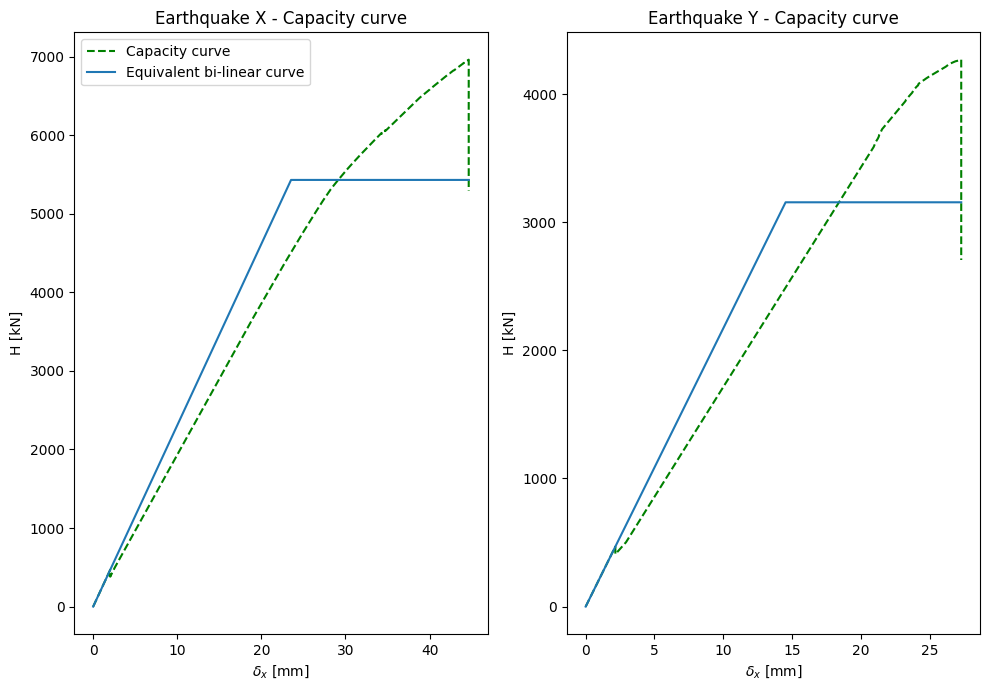

In [15]:
fig1 = S.plot_capacity_curve(S_vr_ult_TOT, S_Hult_TOT, S_v_bl, S_H_bl)

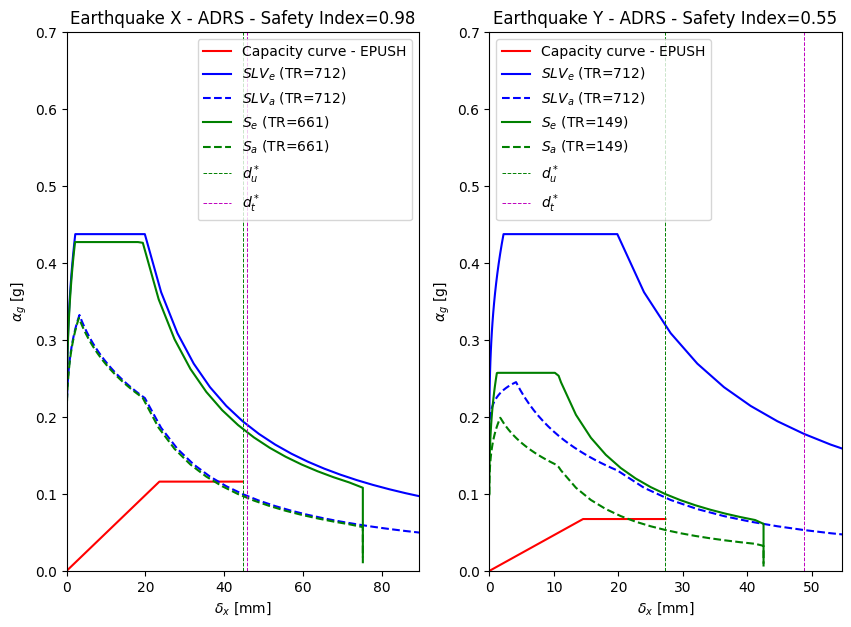

In [16]:
fig2 = S.plot_ADRS_demand_and_capacity(S_v_bl, S_pushover_results)

In [17]:
direction = 'X' # or 'Y'
floor_id = 0

S.plot_failing_walls(S_L_organized, 'X', floor_id)

## Setting VariableSet for update

In [10]:
mean_Estone = 181600
mean_Ebrick = 262200

COV_Estone = 0.39
COV_Ebrick = 0.38

mu_Estone, sigma_Estone = get_mu_and_sigma_of_lognormal(mean_Estone, COV_Estone)
mu_Ebrick, sigma_Ebrick = get_mu_and_sigma_of_lognormal(mean_Ebrick, COV_Ebrick)

a_r = 0.06
b_r = 0.25

P1 = Variable('E_stone', LogNormalDistribution(mu=mu_Estone, sigma=sigma_Estone))
P2 = Variable('E_brick', LogNormalDistribution(mu=mu_Ebrick, sigma=sigma_Ebrick))
P3 = Variable('r_stone', UniformDistribution(a=a_r, b=b_r))
P4 = Variable('r_brick', UniformDistribution(a=a_r, b=b_r))

Q = VariableSet()
Q.add(P1)
Q.add(P2)
Q.add(P3)
Q.add(P4)

In [ ]:
# TODO Upload Q to DKG
Q.get_variables()

{'E_stone': lnN(12.038768563118394, 0.14158636406187075),
 'E_brick': lnN(12.409422609214827, 0.1348804821938182),
 'r_stone': U(0.06, 0.25),
 'r_brick': U(0.06, 0.25)}

## Example predictive model

In [12]:
model = bimquake.BimquakePredictiveModel(S, Q)

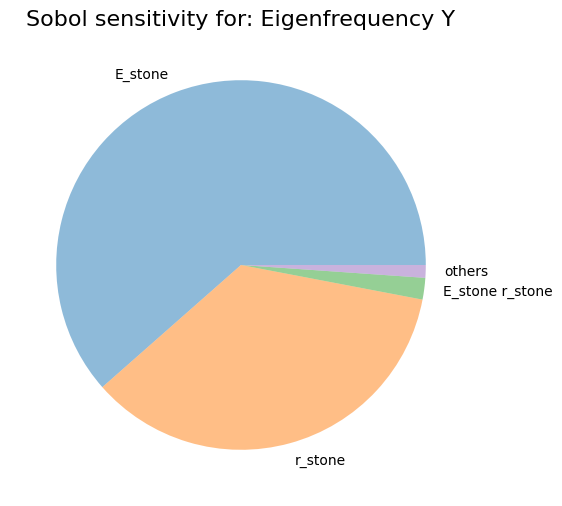

In [22]:
max_index = 2

sobol_index_df, fig = model.get_sobol_sensitivity(['Eigenfrequency Y'], max_index)

In [23]:
sobol_index_df

,E_stone,E_brick,r_stone,r_brick,E_stone E_brick,E_stone r_stone,E_stone r_brick,E_brick r_stone,E_brick r_brick,r_stone r_brick
Eigenfrequency Y,0.6182,0.003871,0.356923,0.002423,0.002368,0.018987,0.001964,0.000092,0.000118,0.000333


## Settings for variable updating

In [ ]:
# TODO upload sigma and z_m (below) to DKG
sigma = [0.02]
E = generate_stndrn_variable_set(sigma)

In [15]:
DT = digital_twinning.DigitalTwin(model, E)

In [17]:
DT.Q.get_variables()

{'E_stone': N(0, 1.00),
 'E_brick': N(0, 1.00),
 'r_stone': U(-1, 1),
 'r_brick': U(-1, 1)}

## MCMC

In [18]:
nwalkers=64
nburn=500
niter=100

z_m = pd.DataFrame([3.1])

In [19]:
DT.update(z_m, nwalkers=nwalkers, nburn=nburn, niter=niter)

MCMC creating
Burning period


100%|██████████| 500/500 [04:53<00:00,  1.70it/s]


MCMC running


100%|██████████| 100/100 [00:58<00:00,  1.72it/s]

--- 353.095974445343 seconds ---


In [20]:
mean_of_post, variance_of_post = DT.get_mean_and_var_of_posterior(scaled=True)
map = DT.get_MAP()
X_train = model.Q.sample(10000)

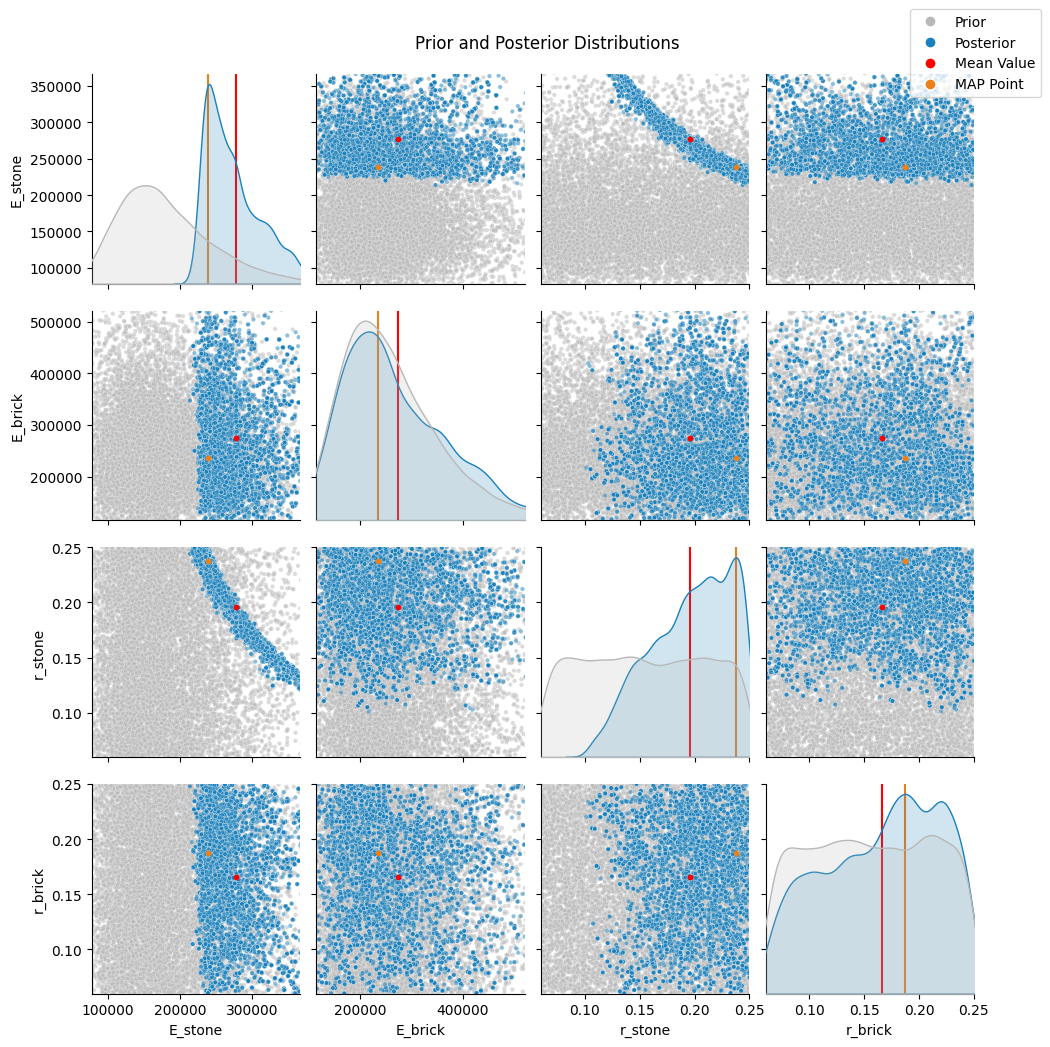

In [22]:
fig = digital_twinning.plot_MCMC(model, X_train, DT, nwalkers=nwalkers, map_point=map)

In [23]:
mean_of_post

,E_stone,E_brick,r_stone,r_brick
0,273880.23799,253576.87505,0.196296,0.165975


In [24]:
map

,E_stone,E_brick,r_stone,r_brick
0,239153.53419,235559.557793,0.238029,0.186989


In [26]:
model.predict(map)

3.121456801840829

In [ ]:
# TODO upload samples and samples_stat to DKG
samples = DT.get_posterior_samples()
samples_stat = digital_twinning.dataframe_statistics_to_json(samples)

## Update values according to MCMC results, using MAP

In [ ]:
model.update_moduli(map.values[0])
S1 = model.model

# TODO upload S1 to DKG

## Linear analysis on new model

In [60]:
S1fs = S1.run_linear_static_analysis(q, q_ort)
S1fs[0]

,Wall_ID,SF_VY,SF_MY,SF_MOY,SF_VX,SF_MX,SF_MOX
0,1,0.827792,0.638722,0.640433,NaN,NaN,NaN
1,2,0.703479,1.577051,0.521261,NaN,NaN,NaN
2,3,0.858934,1.873656,0.664899,NaN,NaN,NaN
3,4,0.475980,0.045711,0.087553,NaN,NaN,NaN
4,5,0.849981,0.497709,0.616903,NaN,NaN,NaN
...,...,...,...,...,...,...,...
118,119,1.302770,0.391707,1.103069,NaN,NaN,NaN
119,120,1.389163,0.849095,1.158764,NaN,NaN,NaN
120,121,1.479483,1.497530,1.218711,NaN,NaN,NaN
121,122,NaN,NaN,NaN,1.39444,1.028493,0.868597


In [61]:
direction = 'Y' # or 'X'
floor_id = 0
safety_factor_type = 'Shear' # or 'Bending in plane' or 'Bending out of plane'

S1.plot_wall_safety_factors(S1fs, direction, floor_id, safety_factor_type)

## Pushover analysis on new model

In [62]:
S1_k_ult_TOT, S1_Hult_TOT, S1_vr_ult_TOT, S1_L_organized = S1.get_force_displacement_capacity_curve(method, algorithm, mu)
S1_v_bl, S1_H_bl = S1.get_bilinear_capacity_curve_coords(S1_vr_ult_TOT, S1_Hult_TOT)
S1_pushover_results = S1.assess_seismic_performance_get_ADRS_params(S1_k_ult_TOT, S1_Hult_TOT, S1_vr_ult_TOT, S1_H_bl, S1_v_bl)

In [63]:
df1 = S1.get_global_vulnerability_metrics(S1_v_bl, S1_pushover_results)
df1

,Direction,Safety Index,PGA_C,TR,δ,d* (t)
0,X,1.26,0.19,1474.0,8.05,23.67
1,Y,0.33,0.05,35.0,3.88,25.04


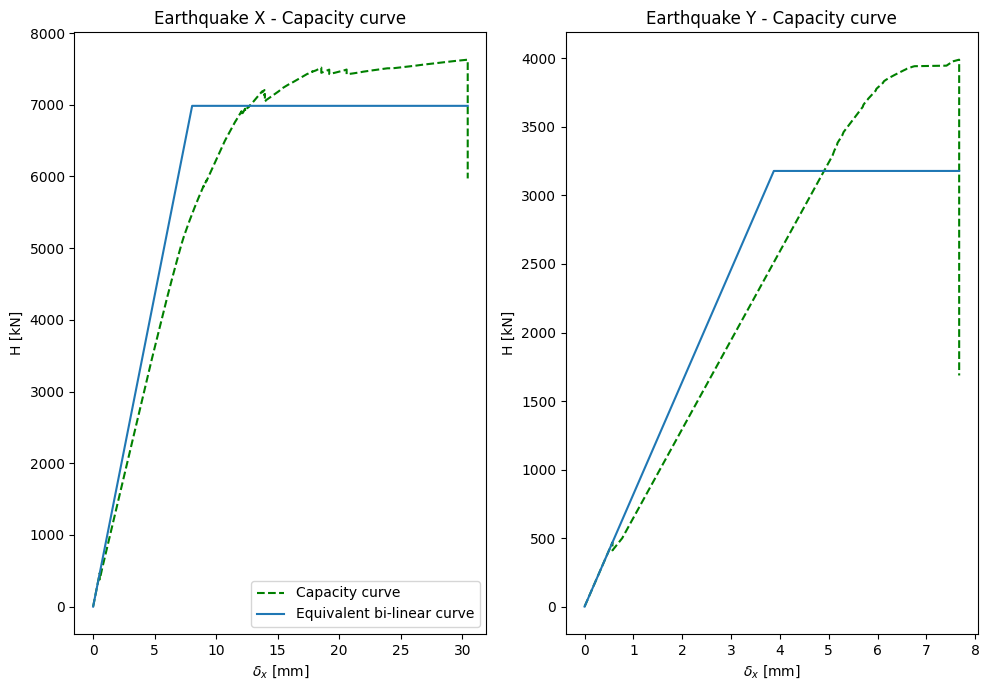

In [64]:
fig1 = S1.plot_capacity_curve(S1_vr_ult_TOT, S1_Hult_TOT, S1_v_bl, S1_H_bl)

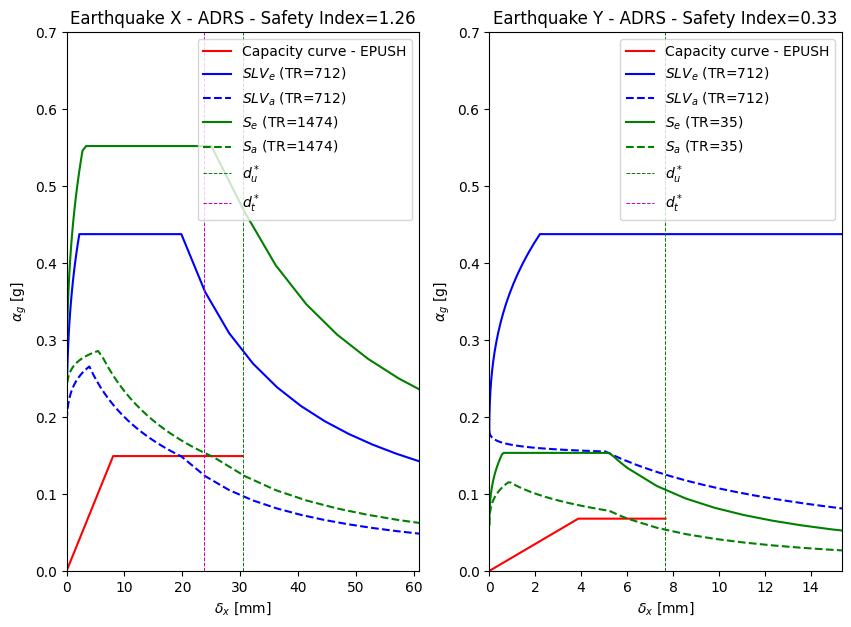

In [65]:
fig2 = S1.plot_ADRS_demand_and_capacity(S1_v_bl, S1_pushover_results)

In [66]:
direction = 'X' # or 'Y'
floor_id = 0

S1.plot_failing_walls(S1_L_organized, 'X', floor_id)

In [ ]:
# TODO upload report on S1 to DKG

## Confidence intervals

In [ ]:
N_samples = 100
samples = DT.get_posterior_samples(scaled=True)
samples = samples.values
results = []
v_bls = []
for i in range(N_samples):
    values = samples[i]
    model.update_moduli(values)
    S = model.model
    k_ult_TOT, Hult_TOT, vr_ult_TOT, L_organized = S.get_force_displacement_capacity_curve(method, algorithm, mu)
    v_bl, H_bl = S.get_bilinear_capacity_curve_coords(vr_ult_TOT, Hult_TOT)
    pushover_results = S.assess_seismic_performance_get_ADRS_params(k_ult_TOT, Hult_TOT, vr_ult_TOT, H_bl, v_bl)
    v_bls.append(v_bl)
    results.append(pushover_results)
    print(f"Sample {i+1}/{N_samples} processed.")

Sample 1/100 processed.
Sample 2/100 processed.
Sample 3/100 processed.
Sample 4/100 processed.
Sample 5/100 processed.
Sample 6/100 processed.
Sample 7/100 processed.
Sample 8/100 processed.
Sample 9/100 processed.
Sample 10/100 processed.
Sample 11/100 processed.
Sample 12/100 processed.
Sample 13/100 processed.
Sample 14/100 processed.
Sample 15/100 processed.
Sample 16/100 processed.
Sample 17/100 processed.
Sample 18/100 processed.
Sample 19/100 processed.
Sample 20/100 processed.
Sample 21/100 processed.
Sample 22/100 processed.
Sample 23/100 processed.
Sample 24/100 processed.
Sample 25/100 processed.
Sample 26/100 processed.
Sample 27/100 processed.
Sample 28/100 processed.
Sample 29/100 processed.
Sample 30/100 processed.
Sample 31/100 processed.
Sample 32/100 processed.
Sample 33/100 processed.
Sample 34/100 processed.
Sample 35/100 processed.
Sample 36/100 processed.
Sample 37/100 processed.
Sample 38/100 processed.
Sample 39/100 processed.
Sample 40/100 processed.
Sample 41

In [ ]:
ADRS = results[0]["ADRS"]

S_eq_x = []
S_eq_y = []
v_bl_x = []
v_bl_y = []
Sda_x = []
Sda_y = []
Saa_x = []
Saa_y = []
Sda_TR_x = []
Sda_TR_y = []
Saa_TR_x = []
Saa_TR_y = []
ADRS_TR_x_x = []
ADRS_TR_y_x = []
ADRS_TR_x_y = []
ADRS_TR_y_y = []
dxstar_x = []
dxstar_y = []
IR = []

for i in range(N_samples):
    S_eq_x.append(results[i]["S_eq"][0])
    S_eq_y.append(results[i]["S_eq"][1])
    v_bl_x.append(v_bls[i][0])
    v_bl_y.append(v_bls[i][1])
    Sda_x.append(results[i]["Sda"][0])
    Sda_y.append(results[i]["Sda"][1])
    Saa_x.append(results[i]["Saa"][0])
    Saa_y.append(results[i]["Saa"][1])
    Sda_TR_x.append(results[i]["Sda_TR"][0])
    Sda_TR_y.append(results[i]["Sda_TR"][1])
    Saa_TR_x.append(results[i]["Saa_TR"][0])
    Saa_TR_y.append(results[i]["Saa_TR"][1])
    ADRS_TR_x_x.append(results[i]["ADRS_TR"][0][:, 0])
    ADRS_TR_y_x.append(results[i]["ADRS_TR"][1][:, 0])
    ADRS_TR_x_y.append(results[i]["ADRS_TR"][0][:, 1])
    ADRS_TR_y_y.append(results[i]["ADRS_TR"][1][:, 1])
    dxstar_x.append(results[i]["dxstars"][0])
    dxstar_y.append(results[i]["dxstars"][1])
    IR.append(results[i]["IR"])

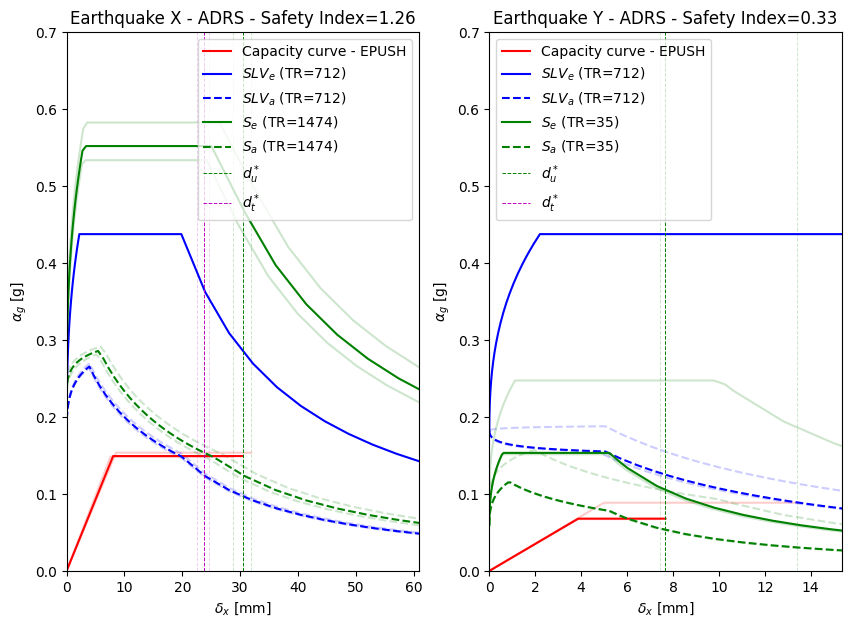

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(10, 7))
directions = ['X', 'Y']

ax[0].plot(np.min(v_bl_x, axis=0), np.min(S_eq_x, axis=0), 'r-', alpha=0.2)
ax[0].plot(np.max(v_bl_x, axis=0), np.max(S_eq_x, axis=0), 'r-', alpha=0.2)

ax[0].plot(np.min(Sda_x, axis=0), np.min(Saa_x, axis=0), 'b--', alpha=0.2)
ax[0].plot(np.max(Sda_x, axis=0), np.max(Saa_x, axis=0), 'b--', alpha=0.2)

ax[0].plot(np.min(ADRS_TR_x_x, axis=0), np.min(ADRS_TR_x_y, axis=0), 'g-', alpha=0.2)
ax[0].plot(np.max(ADRS_TR_x_x, axis=0), np.max(ADRS_TR_x_y, axis=0), 'g-', alpha=0.2)

ax[0].plot(np.min(Sda_TR_x, axis=0), np.min(Saa_TR_x, axis =0), 'g--', alpha=0.2)
ax[0].plot(np.max(Sda_TR_x, axis=0), np.max(Saa_TR_x, axis =0), 'g--', alpha=0.2)

ax[0].axvline(np.min(v_bl_x, axis=0)[2], color='g', ls='--', linewidth=0.7, alpha=0.2)
ax[0].axvline(np.max(v_bl_x, axis=0)[2], color='g', ls='--', linewidth=0.7, alpha=0.2)

ax[0].axvline(np.min(dxstar_x), color='m', ls='--', linewidth=0.7, alpha=0.2)
ax[0].axvline(np.max(dxstar_x), color='m', ls='--', linewidth=0.7, alpha=0.2)

ax[0].set_ylim([0, 0.7])
ax[0].set_xlim([0, np.max(v_bl_x)*2])

#----------------------------------------------------------------------------#

ax[1].plot(np.min(v_bl_y, axis=0), np.min(S_eq_y, axis=0), 'r-', alpha=0.2)
ax[1].plot(np.max(v_bl_y, axis=0), np.max(S_eq_y, axis=0), 'r-', alpha=0.2)

ax[1].plot(np.min(Sda_y, axis=0), np.min(Saa_y, axis=0), 'b--', alpha=0.2)
ax[1].plot(np.max(Sda_y, axis=0), np.max(Saa_y, axis=0), 'b--', alpha=0.2)

ax[1].plot(np.min(ADRS_TR_y_x, axis=0), np.min(ADRS_TR_y_y, axis=0), 'g-', alpha=0.2)
ax[1].plot(np.max(ADRS_TR_y_x, axis=0), np.max(ADRS_TR_y_y, axis=0), 'g-', alpha=0.2)


ax[1].plot(np.min(Sda_TR_y, axis=0), np.min(Saa_TR_y, axis =0), 'g--', alpha=0.2)
ax[1].plot(np.max(Sda_TR_y, axis=0), np.max(Saa_TR_y, axis =0), 'g--', alpha=0.2)

ax[1].axvline(np.min(v_bl_y, axis=0)[2], color='g', ls='--', linewidth=0.7, alpha=0.2)
ax[1].axvline(np.max(v_bl_y, axis=0)[2], color='g', ls='--', linewidth=0.7, alpha=0.2)

ax[1].axvline(np.min(dxstar_y), color='m', ls='--', linewidth=0.7, alpha=0.2)
ax[1].axvline(np.max(dxstar_y), color='m', ls='--', linewidth=0.7, alpha=0.2)

ax[1].set_ylim([0, 0.7])
ax[1].set_xlim([0, np.max(v_bl_y)*2])


for i in range(len(directions)):
    pushover_results = S1_pushover_results
    v_bl = S1_v_bl
    
    Sda = pushover_results["Sda"]
    Saa = pushover_results["Saa"]
    S_eq = pushover_results["S_eq"]
    dxstar_t = pushover_results["dxstars"]
    Tr = pushover_results["Tr"]
    IR = pushover_results["IR"]
    ADRS_TR = pushover_results["ADRS_TR"]
    Sda_TR = pushover_results["Sda_TR"]
    Saa_TR = pushover_results["Saa_TR"]
    tstep = pushover_results["t_step"]
    ADRS = pushover_results["ADRS"]

    ax[i].plot(v_bl[i], S_eq[i], 'r-', label='Capacity curve - EPUSH')

    ax[i].plot(ADRS[:, 0], ADRS[:, 1], 'b-', label='$SLV_e$ (TR=712)')
    ax[i].plot(Sda[i], Saa[i], 'b--', label='$SLV_a$ (TR=712)')

    ax[i].plot(ADRS_TR[i][:, 0], ADRS_TR[i][:, 1], 'g-', label='$S_e$ (TR={})'.format(Tr[i]))
    ax[i].plot(Sda_TR[i], Saa_TR[i], 'g--', label='$S_a$ (TR={})'.format(Tr[i]))

    ax[i].set_ylim([0, 0.7])
    ax[i].set_xlim([0, np.max(v_bl[i])*2])

    ax[i].set_ylabel('$α_g$ [g]')
    ax[i].set_xlabel('$δ_x$ [mm]')
    ax[i].axvline(v_bl[i][2], color='g', ls='--', linewidth=0.7, label='$d_u^*$')
    ax[i].axvline(dxstar_t[i], color='m', ls='--', linewidth=0.7, label='$d_t^*$')

    if Tr == 2475:
        ax[i].title.set_text('Earthquake {} - ADRS - Safety Index>{}'.format(directions[i], IR[i]))
    else:
        ax[i].title.set_text('Earthquake {} - ADRS - Safety Index={}'.format(directions[i], IR[i]))
    ax[i].legend()

In [149]:
IR_df = pd.DataFrame(np.array(IR), columns=['IR_X', 'IR_Y'])
IR_df.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

,count,mean,std,min,5%,25%,50%,75%,95%,max
IR_X,100.0,1.2744,0.027536,1.22,1.23,1.2600,1.27,1.30,1.320,1.33
IR_Y,100.0,0.3551,0.036529,0.33,0.33,0.3375,0.35,0.36,0.365,0.52
